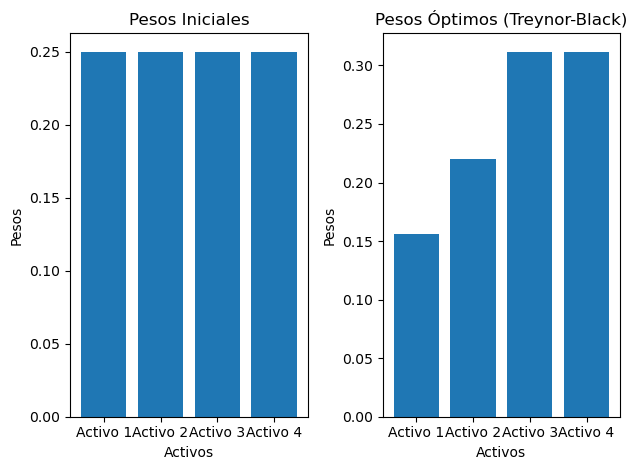

          Rendimiento Promedio  Volatilidad  Coeficiente Treynor  \
Activo 1                  0.08     0.200000             0.400000   
Activo 2                  0.06     0.141421             0.424264   
Activo 3                  0.05     0.100000             0.500000   
Activo 4                  0.04     0.100000             0.400000   

          Pesos Óptimos (Treynor-Black)  
Activo 1                       0.155904  
Activo 2                       0.220481  
Activo 3                       0.311808  
Activo 4                       0.311808  


In [1]:
# Ejemplo Método  de Traynor- Black

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Datos de entrada
rendimientos_activos = pd.DataFrame({
    'Activo 1': [0.08, 0.10, 0.12],
    'Activo 2': [0.06, 0.07, 0.09],
    'Activo 3': [0.05, 0.08, 0.11],
    'Activo 4': [0.04, 0.06, 0.08]
}, index=['Año 1', 'Año 2', 'Año 3'])

covarianza_activos = pd.DataFrame({
    'Activo 1': [0.04, 0.02, 0.01],
    'Activo 2': [0.02, 0.03, 0.01],
    'Activo 3': [0.01, 0.01, 0.02],
    'Activo 4': [0.01, 0.01, 0.03]
}, index=['Año 1', 'Año 2', 'Año 3'])

pesos_iniciales = np.array([0.25, 0.25, 0.25, 0.25])

# Cálculo del rendimiento promedio y volatilidad del año 1
rendimientos_promedio = rendimientos_activos.loc['Año 1']
volatilidad = np.sqrt(covarianza_activos.loc['Año 1', 'Activo 1':'Activo 4'].values)

# Cálculo de los coeficientes de Treynor
coeficientes_treynor = rendimientos_promedio / volatilidad

# Cálculo de los pesos óptimos utilizando el enfoque Treynor-Black
w_treynor_black = (pesos_iniciales / volatilidad) / np.sum(pesos_iniciales / volatilidad)

# Gráfico de barras de los pesos iniciales
plt.subplot(1, 2, 1)
plt.bar(range(len(pesos_iniciales)), pesos_iniciales)
plt.title('Pesos Iniciales')
plt.xlabel('Activos')
plt.ylabel('Pesos')
plt.xticks(range(len(pesos_iniciales)), rendimientos_activos.columns)

# Gráfico de barras de los pesos óptimos según el enfoque Treynor-Black
plt.subplot(1, 2, 2)
plt.bar(range(len(w_treynor_black)), w_treynor_black)
plt.title('Pesos Óptimos (Treynor-Black)')
plt.xlabel('Activos')
plt.ylabel('Pesos')
plt.xticks(range(len(w_treynor_black)), rendimientos_activos.columns)

# Mostrar los gráficos
plt.tight_layout()
plt.show()

# Resultados
resultados = pd.DataFrame({
    'Rendimiento Promedio': rendimientos_promedio,
    'Volatilidad': volatilidad,
    'Coeficiente Treynor': coeficientes_treynor,
    'Pesos Óptimos (Treynor-Black)': w_treynor_black
}, index=rendimientos_activos.columns)

print(resultados)